# Dataset Analysis

In [48]:
import cv2
import json
import pathlib
import datetime
import pandas as pd
import numpy as np
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt

root_dir = pathlib.Path('../../../data')
ann_dir = pathlib.Path(root_dir, 'folder_structure/supervisely/wrist/ann')

dataset_path = pathlib.Path(root_dir, 'dataset.csv')

In [14]:
df = pd.read_csv(dataset_path)
df.head(10)

,filestem,patient_id,study_number,timehash,gender,age,laterality,projection,initial_exam,ao_classification,cast,diagnosis_uncertain,osteopenia,fracture_visible,metal,pixel_spacing,device_manufacturer
0,0001_1297860395_01_WRI-L1_M014,1,1,1297860395,M,14.1,L,1,1.0,23r-M/2.1,NaN,NaN,NaN,NaN,NaN,0.144,Siemens
1,0001_1297860435_01_WRI-L2_M014,1,1,1297860435,M,14.1,L,2,1.0,23r-M/2.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens
2,0002_0354485735_01_WRI-R1_F012,2,1,354485735,F,12.0,R,1,1.0,23r-M/2.1,NaN,1.0,NaN,NaN,NaN,0.144,Siemens
3,0002_0354485759_01_WRI-R2_F012,2,1,354485759,F,12.0,R,2,1.0,23r-M/2.1,NaN,1.0,NaN,NaN,NaN,0.144,Siemens
4,0003_0662359226_01_WRI-R1_M011,3,1,662359226,M,11.1,R,1,1.0,23-M/3.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens
5,0003_0662359351_01_WRI-R2_M011,3,1,662359351,M,11.1,R,2,1.0,23-M/3.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens
6,0003_0663715732_02_WRI-R1_M011,3,2,663715732,M,11.2,R,1,NaN,23-M/3.1,1.0,NaN,NaN,1.0,NaN,0.144,Siemens
7,0003_0663715782_02_WRI-R2_M011,3,2,663715782,M,11.2,R,2,NaN,23-M/3.1,1.0,NaN,NaN,1.0,NaN,0.144,Siemens
8,0003_0664918633_03_WRI-R1_M011,3,3,664918633,M,11.2,R,1,NaN,23-M/3.1,NaN,NaN,1.0,1.0,NaN,0.144,Siemens
9,0003_0664918693_03_WRI-R2_M011,3,3,664918693,M,11.2,R,2,NaN,23-M/3.1,NaN,NaN,1.0,1.0,NaN,0.144,Siemens


In [8]:
n_rows = df.shape[0]
n_cols = df.shape[1]

print(f'Dataset shape: {df.shape}')

Dataset shape: (20327, 17)


In [3]:
n_patients = df['patient_id'].nunique()
print(f'Number of distinct patients: {n_patients}')

Number of distinct patients: 6091


In [6]:
min_age = df['age'].min()
max_age = df['age'].max()

print(f'Youngest patient: {min_age}')
print(f'Oldest patient: {max_age}')

Youngest patient: 0.2
Oldest patient: 19.0


In [10]:
n_left = (df['laterality'] == 'L').sum()
n_right = (df['laterality'] == 'R').sum()

print(f'Number of left-wrist pictures: {n_left} ({(n_left / n_rows * 100):.2f}%)')
print(f'Number of right-wrist pictures: {n_right} ({(n_right / n_rows * 100):.2f}%)')


Number of left-wrist pictures: 11135 (54.78%)
Number of right-wrist pictures: 9192 (45.22%)


In [17]:
n_male = (df.drop_duplicates(subset='patient_id')['gender'] == 'M').sum()
n_female = (df.drop_duplicates(subset='patient_id')['gender'] == 'F').sum()

print(f'Number of male patients: {n_male} ({(n_male / n_patients * 100):.2f}%)')
print(f'Number of female patients: {n_female} ({(n_female / n_patients * 100):.2f}%)')

Number of male patients: 3401 (55.84%)
Number of female patients: 2689 (44.15%)


In [13]:
n_uncertain = (df['diagnosis_uncertain'] == 1.0).sum()

print(f'Number of uncertain diagnoses: {n_uncertain} ({(n_uncertain / n_rows * 100):.2f}%)')

Number of uncertain diagnoses: 537 (2.64%)


In [63]:
n_duplicates = df.duplicated().sum()

print(f'Number of duplicates: {n_duplicates}')

Number of duplicates: 0


In [65]:
missing = [
    f for f in df['filestem']
    if not (ann_dir / f"{f}.json").exists()
]

print(f'Missing number of annotations: {len(missing)}')

Missing number of annotations: 0


In [67]:
empty = []
for f in df['filestem']:
    data = json.loads((ann_dir / f"{f}.json").read_text())
    if len(data.get("objects", [])) == 0:
        empty.append(f)

print(f'Number of empty annotation: {len(empty)}')

Number of empty annotation: 0


In [31]:
images_per_patient = df.groupby('patient_id').size()

print(images_per_patient.describe())

count    6091.000000
mean        3.337219
std         2.533628
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        30.000000
dtype: float64


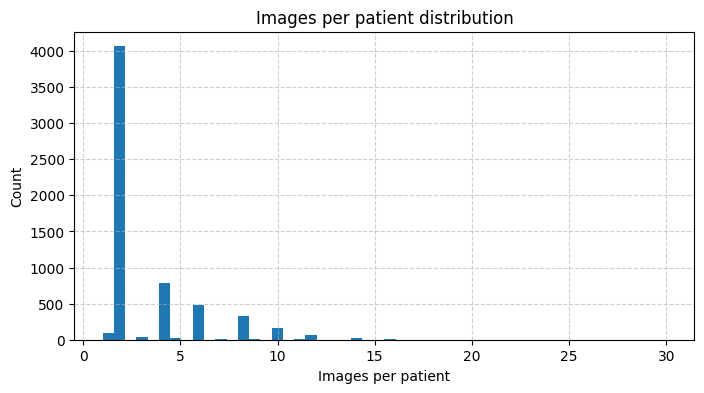

In [32]:
plt.figure(figsize=(8, 4))
plt.hist(images_per_patient, bins=50)
plt.title('Images per patient distribution')
plt.xlabel('Images per patient')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [34]:
def get_classes_for_image(filestem: str):
    ann_path = ann_dir / f"{filestem}.json"
    data = json.loads(ann_path.read_text())

    object_classes = sorted({
        obj["classTitle"]
        for obj in data.get("objects", [])
        if obj["classTitle"] != "axis"
    })

    return object_classes

df_objects = df.copy()
df_objects['objects'] = df['filestem'].apply(lambda x: get_classes_for_image(x))
df_objects.head()


,filestem,patient_id,study_number,timehash,gender,age,laterality,projection,initial_exam,ao_classification,cast,diagnosis_uncertain,osteopenia,fracture_visible,metal,pixel_spacing,device_manufacturer,objects
0,0001_1297860395_01_WRI-L1_M014,1,1,1297860395,M,14.1,L,1,1.0,23r-M/2.1,NaN,NaN,NaN,NaN,NaN,0.144,Siemens,[text]
1,0001_1297860435_01_WRI-L2_M014,1,1,1297860435,M,14.1,L,2,1.0,23r-M/2.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens,"[fracture, pronatorsign, text]"
2,0002_0354485735_01_WRI-R1_F012,2,1,354485735,F,12.0,R,1,1.0,23r-M/2.1,NaN,1.0,NaN,NaN,NaN,0.144,Siemens,[text]
3,0002_0354485759_01_WRI-R2_F012,2,1,354485759,F,12.0,R,2,1.0,23r-M/2.1,NaN,1.0,NaN,NaN,NaN,0.144,Siemens,[text]
4,0003_0662359226_01_WRI-R1_M011,3,1,662359226,M,11.1,R,1,1.0,23-M/3.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens,"[fracture, text]"


In [42]:
all_labels = [label for sublist in df_objects['objects'] for label in sublist ]
label_counts = Counter(all_labels)
label_counts_df = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count'])
label_counts_df = label_counts_df.sort_values(by='count', ascending=False)

print(label_counts_df)

                    count
text                20274
fracture            13550
periostealreaction   2235
metal                 708
pronatorsign          566
softtissue            439
boneanomaly           192
bonelesion             42
foreignbody             8


<Figure size 1000x500 with 0 Axes>

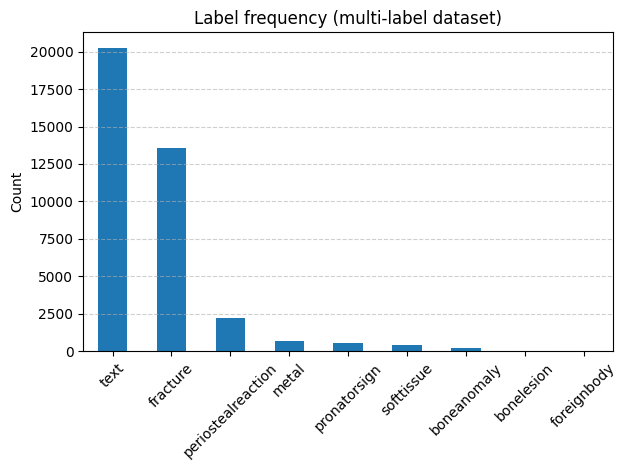

In [43]:
plt.figure(figsize=(10, 5))

label_counts_df.plot(kind='bar', legend=False)

plt.title('Label frequency (multi-label dataset)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [70]:
df_objects['n_labels'] = df_objects['objects'].apply(len)

df_objects['n_labels'].describe()

count    20327.000000
mean         1.870123
std          0.713070
min          0.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          5.000000
Name: n_labels, dtype: float64

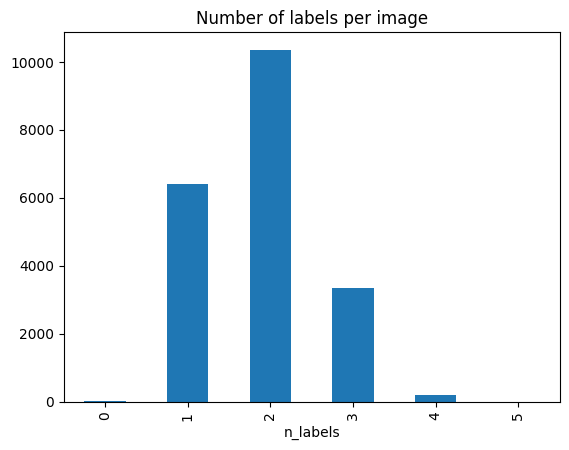

In [71]:
df_objects['n_labels'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of labels per image")
plt.show()

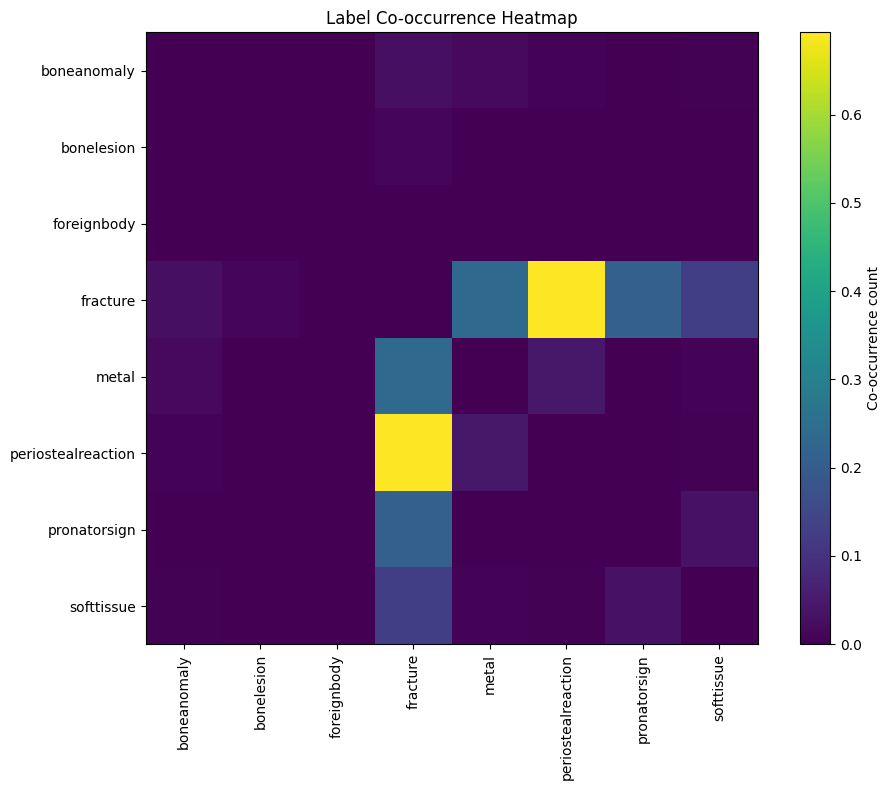

In [62]:
pairs = []

for labels in df_objects['objects']:
    for a, b in combinations(sorted(set(labels)), 2):
        pairs.append((a, b))

pair_counts = Counter(pairs)

labels = sorted(
  set([l for sub in df_objects['objects'] for l in sub])
)

matrix = pd.DataFrame(0, index=labels, columns=labels)

for (a, b), count in pair_counts.items():
  matrix.loc[a, b] = count
  matrix.loc[b, a] = count

labels = [l for l in labels if l != 'text']
matrix = matrix.loc[labels, labels]
matrix = matrix / matrix.max().max()
matrix = np.log1p(matrix)

plt.figure(figsize=(10, 8))
plt.imshow(matrix, interpolation='nearest')

plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)

plt.colorbar(label='Co-occurrence count')
plt.title('Label Co-occurrence Heatmap')

plt.tight_layout()
plt.show()

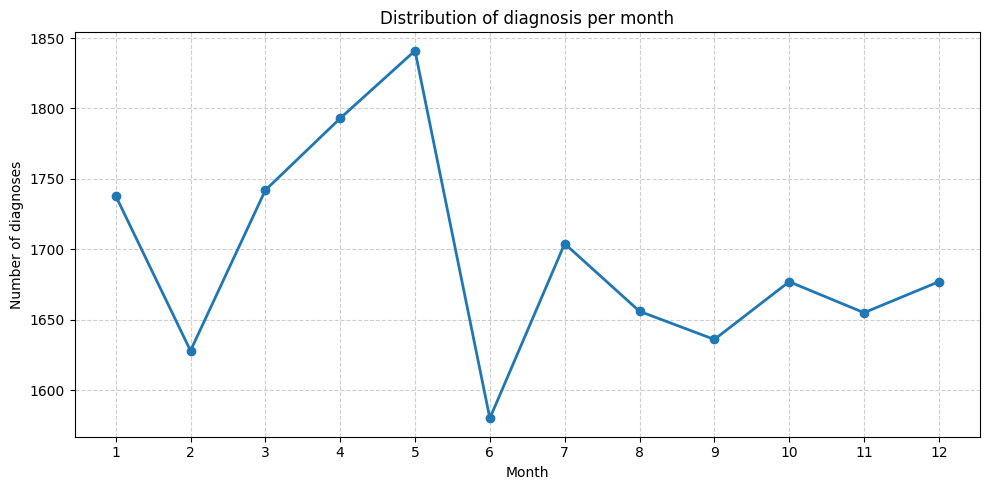

In [27]:
df_months = df.copy()
df_months['month'] = df_months['timehash'].apply(lambda x: datetime.datetime.fromtimestamp(x).month)
monthly_counts = df_months['month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
  monthly_counts.index,
  monthly_counts.values,
  marker='o',
  linewidth=2
)

plt.title('Distribution of diagnoses per month')
plt.xlabel('Month')
plt.ylabel('Number of diagnoses')

plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

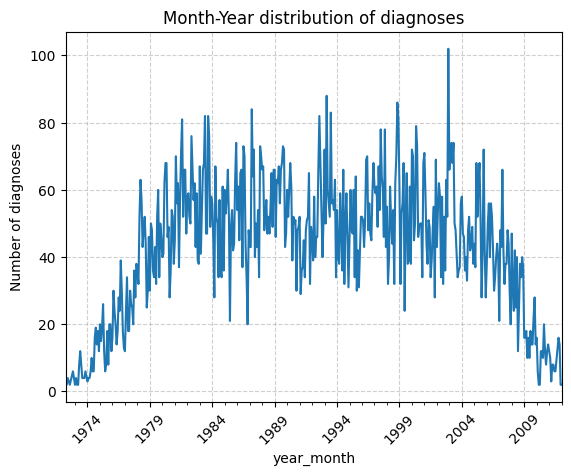

In [79]:
df_months['datetime'] = df_months['timehash'].apply(datetime.datetime.fromtimestamp)
df_months['year_month'] = df_months['datetime'].dt.to_period('M')

ax = df_months['year_month'].value_counts().sort_index().plot(
    title='Month-Year distribution of diagnoses',
    ylabel='Number of diagnoses'
)

ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.show()

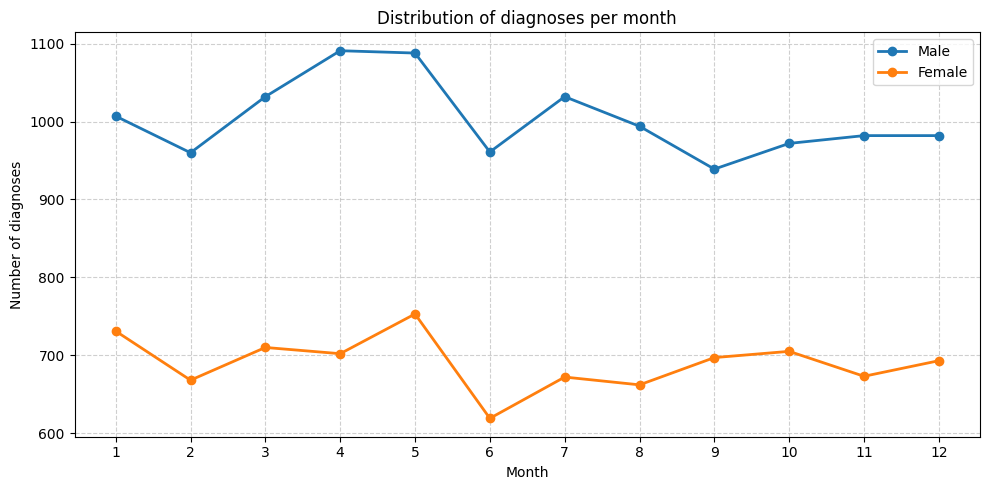

In [30]:
df_months = df.copy()
df_months['month'] = df_months['timehash'].apply(lambda x: datetime.datetime.fromtimestamp(x).month)
monthly_counts_M = df_months[df_months['gender'] == 'M']['month'].value_counts().sort_index()
monthly_counts_F = df_months[df_months['gender'] == 'F']['month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
  monthly_counts_M.index,
  monthly_counts_M.values,
  marker='o',
  linewidth=2,
  label='Male'
)

plt.plot(
  monthly_counts_F.index,
  monthly_counts_F.values,
  marker='o',
  linewidth=2,
  label='Female'
)

plt.title('Distribution of diagnoses per month')
plt.xlabel('Month')
plt.ylabel('Number of diagnoses')

plt.legend()
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()